In [9]:
%matplotlib inline
%config InlineBackend.figure_formats={'png','retina'}
import numpy as np
np.set_printoptions(precision=2, suppress=True)
import time
import os
import itertools
import importlib
import pandas as pd
from tqdm import tqdm

from scipy.stats import zscore, pearsonr
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error

from utils import plot_functions
from utils import training_utils
import shap
import matplotlib.pyplot as plt

# import importlib
# importlib.reload(plot_functions)


COLOR_DICT = {
    '2016_Furukawa': '#4B73B0',
    '2020_Furukawa': '#DD8553',
    '2021_Kelly': '#55A868',
    '2022_Bhardwaj': '#C54F53',
    'Wang2021': '#8172B3',
    '2D': '#3F3E3C',
    '3D': '#F2B53B',
    'PS3D': '#F18274',
    'diffPS3D': '#D83F37'
}


### Data import
+ 735 dims
+ 2D:   188type 188dims
+ 3D:    49type  49dims
+ PS3D:  82type 246dims
+ ∆PS3D: 84type 252dims
+ index 0-251: training data
+ All descriptors were standardized on the training data.

In [15]:
# NOTE: AlogP>4のものを除外
unuse_name = ['D10.21', 'D10.22', 'D10.23', 'D8.21']

df = pd.read_csv('data/y.csv', index_col=0).drop(unuse_name, axis=0).reset_index(drop=True)
y = df['PAMPA'].to_numpy()
df_desc = pd.read_csv('data/descriptors.csv', index_col=0).drop(unuse_name, axis=0).reset_index(drop=True)


# IMPORTANT: apply Z-score
X = df_desc.copy()
for _ in df_desc:
    X[_] = (X[_] - df_desc.iloc[:252].mean()[_]) / df_desc.iloc[:252].std()[_]

print(X.shape)

(276, 735)


### Import descriptors for learning

In [16]:
th = 0.6

use_features = pd.read_csv(f'data/use_features_th{th}.csv')['feature'].to_list()
X = X[use_features]
print(X.shape)

(276, 94)


### Import indices for 5-fold cv

In [17]:
# 5-fold cv
cv = 5

train_index_cv, test_index_cv = {}, {}
for i in range(cv):
    train_index_cv[i] = np.load(f'data/eval_index/train_index_cv{i}.npy')
    test_index_cv[i]  = np.load(f'data/eval_index/test_index_cv{i}.npy')

new_data_index = np.array(list(range(252, 252+24)))

### PCA analysis

In [18]:
pca = PCA(n_components=3)
pca.fit(X.iloc[:252])
print(pca.explained_variance_ratio_)

transformed_data = pca.transform(X)

pca_components = pd.DataFrame(pca.components_, columns=X.columns, index=["PC{}".format(x + 1) for x in range(3)]).T

[0.09 0.08 0.05]


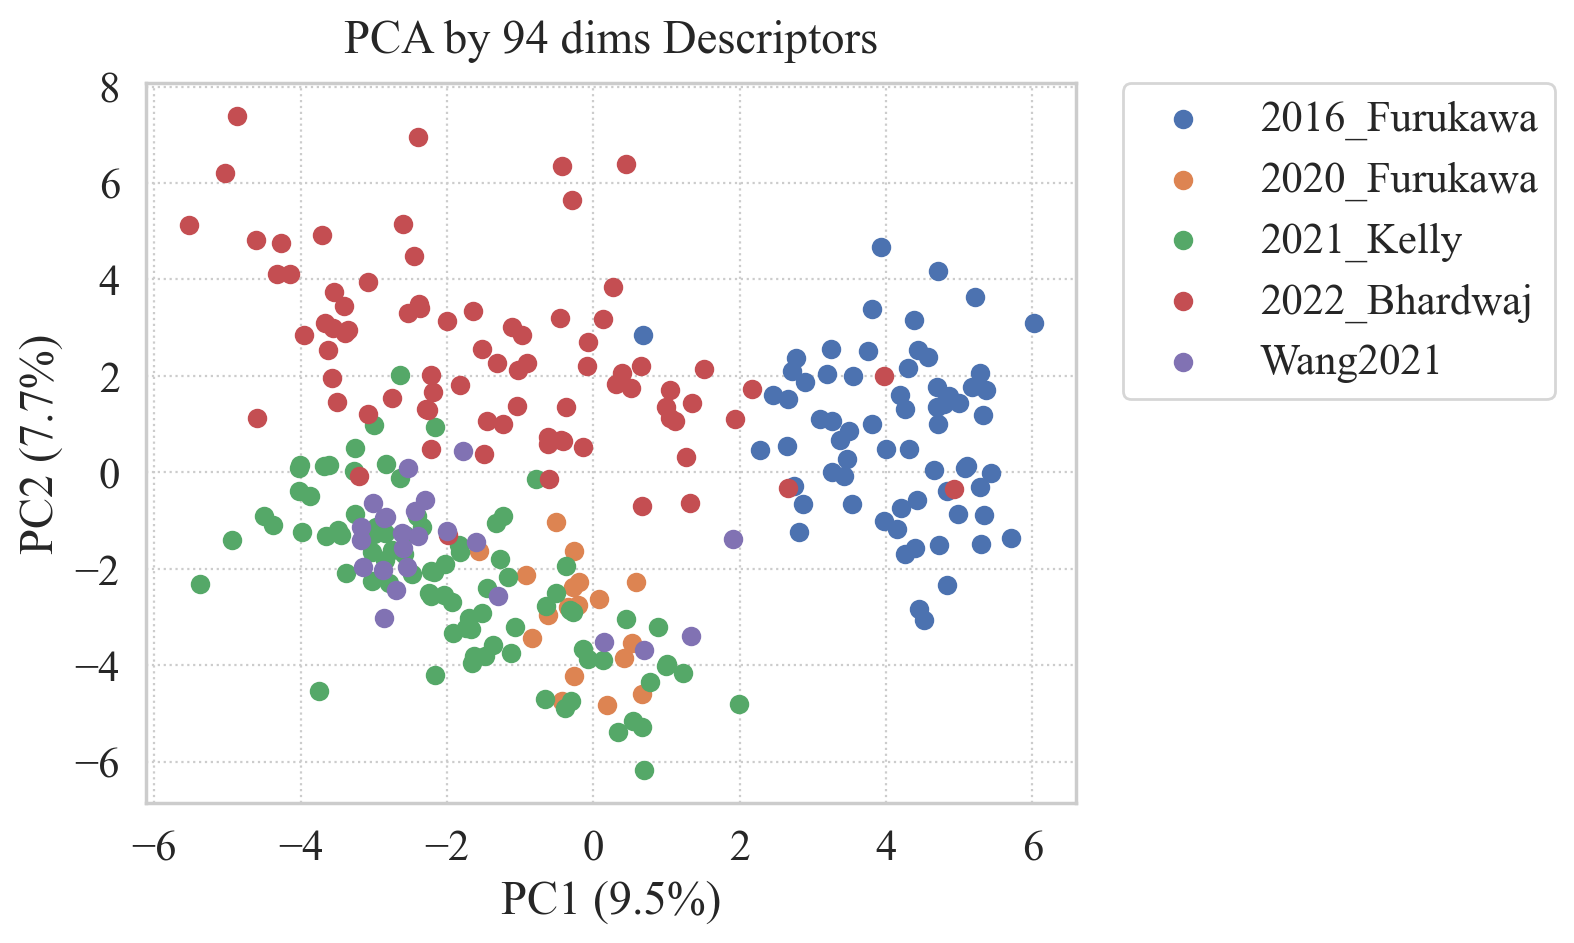

In [19]:
set_name = ['2016_Furukawa', '2020_Furukawa', '2021_Kelly', '2022_Bhardwaj', 'Wang2021']
title = f'PCA by {len(use_features)} dims Descriptors'

plot_functions.plot_PCA_space_all_sets(
    pca,
    [transformed_data[df[df['Set']==now_set].index.to_list()] for now_set in set_name],
    set_name,
    '',
    title=title,
    legend_outside=True,
    save_fig=False,
    )

### Test external data

In [27]:
model_name = ['Lasso', 'Ridge', 'SVM', 'RF', 'XGBoost', 'LightGBM']
#model_name = ['XGBoost']
os.makedirs('predicted', exist_ok=True)
os.makedirs('predicted/test_2', exist_ok=True)


for name in model_name:
    df_search_results = pd.read_csv(f'weight/{name}_search_results.csv')
    best_params = df_search_results.iloc[df_search_results['MAE'].idxmin()]

    model = training_utils.create_model(name, is_search=False, best_params=best_params)


    metrics_list = []
    preds_all = []
    #preds = []
    for i in range(cv):
        model.fit(X.iloc[train_index_cv[i]].to_numpy(), y[train_index_cv[i]])
        
        # CHANGED
        y_pred = model.predict(X.iloc[new_data_index].to_numpy())
        preds_all.append(y_pred.tolist())

        MAE, RMSE, R, MSE, R2 = training_utils.evaluate_model(y[new_data_index], y_pred, round_num=5)    

        metrics_list.append([MAE, RMSE, R, MSE, R2])        
        

    metrics_df = pd.DataFrame(
        metrics_list,
        columns=['MAE', 'RMSE', 'R', 'MSE', 'R2']
    )    

    metrics_mean = metrics_df.mean()
    metrics_std = metrics_df.std()    

    metrics_summary = pd.DataFrame({
        'mean': metrics_mean,
        'std': metrics_std
    })    

    metrics_df.to_csv(f'predicted/test_2/{name}_newdata_metrics_each_cv.csv')
    metrics_summary.to_csv(f'predicted/test_2/{name}_newdata_metrics_mean_std.csv')
    preds_all_df = pd.DataFrame(preds_all).T  # shape: [データ数 × CV]
    preds_all_df.index = new_data_index
    preds_all_df.to_csv(f'predicted/test_2/{name}_newdata_preds_each_cv.csv')    


    #pred = pd.DataFrame({'exp': y[new_data_index], 'pred': preds_ave}, index=new_data_index).sort_index()
    #pred.to_csv(f'predicted/test_2/{name}_newdata_predicted.csv')

In [28]:
#model_name = ['Lasso', 'Ridge', 'SVM', 'RF', 'XGBoost', 'LightGBM']
model_name = ['XGBoost']
for name in model_name:
    metrics = pd.read_csv(f'predicted/test_2/{name}_newdata_metrics_mean_std.csv', index_col=0)
    print(name)
    for met in metrics.index:     # ← 列ではなく行（指標名）を回す
        if met != 'MSE':
            print(f"{met:4}: {metrics.loc[met,'mean']:.2f} ± {metrics.loc[met,'std']:.2f}")
                #print(f"{_:4}: {'{:0.2f}'.format(metrics[_].loc['mean'])} ± {'{:0.2f}'.format(metrics[_].loc['std'])}")
                #print(f"{_:4}: {'{:0.2f}'.format(metrics[_].loc[0])}")
    print()

XGBoost
MAE : 0.96 ± 0.03
RMSE: 1.14 ± 0.03
R   : 0.76 ± 0.01
R2  : -0.07 ± 0.05



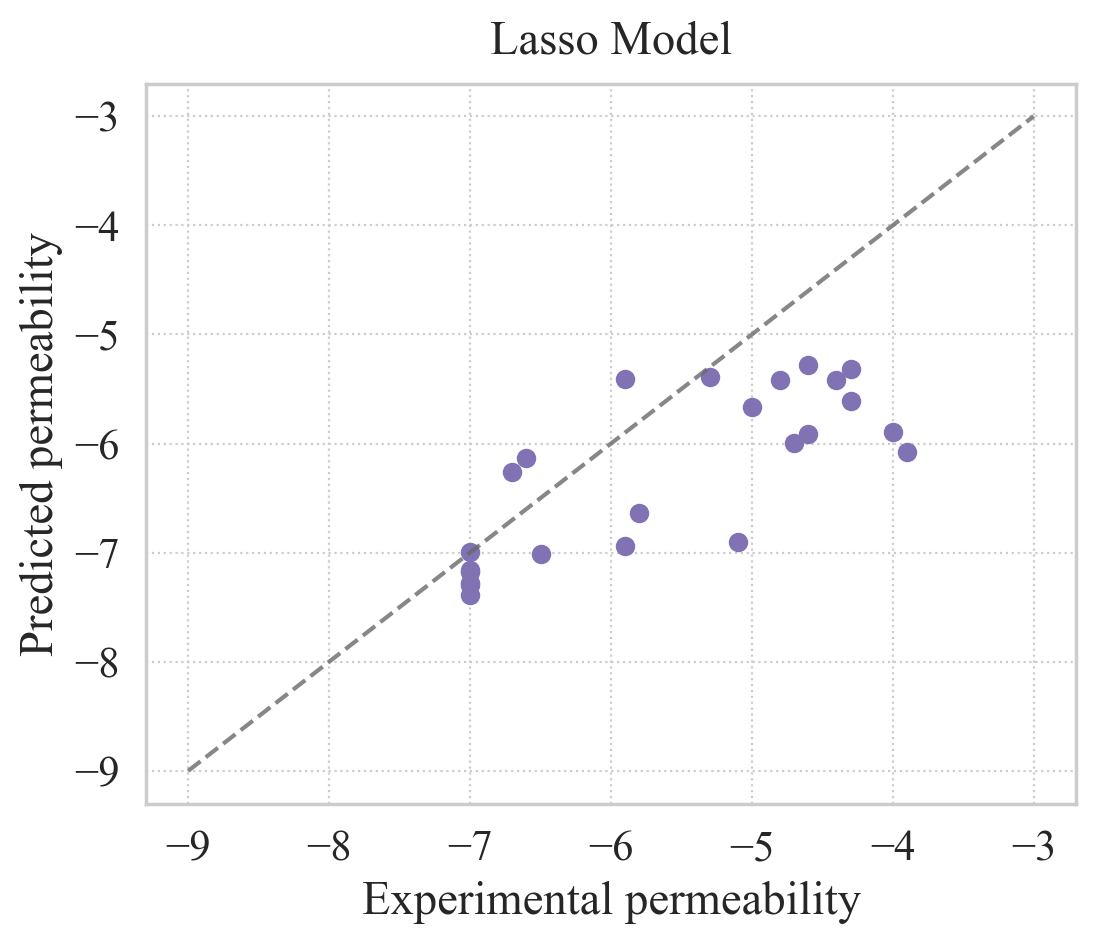

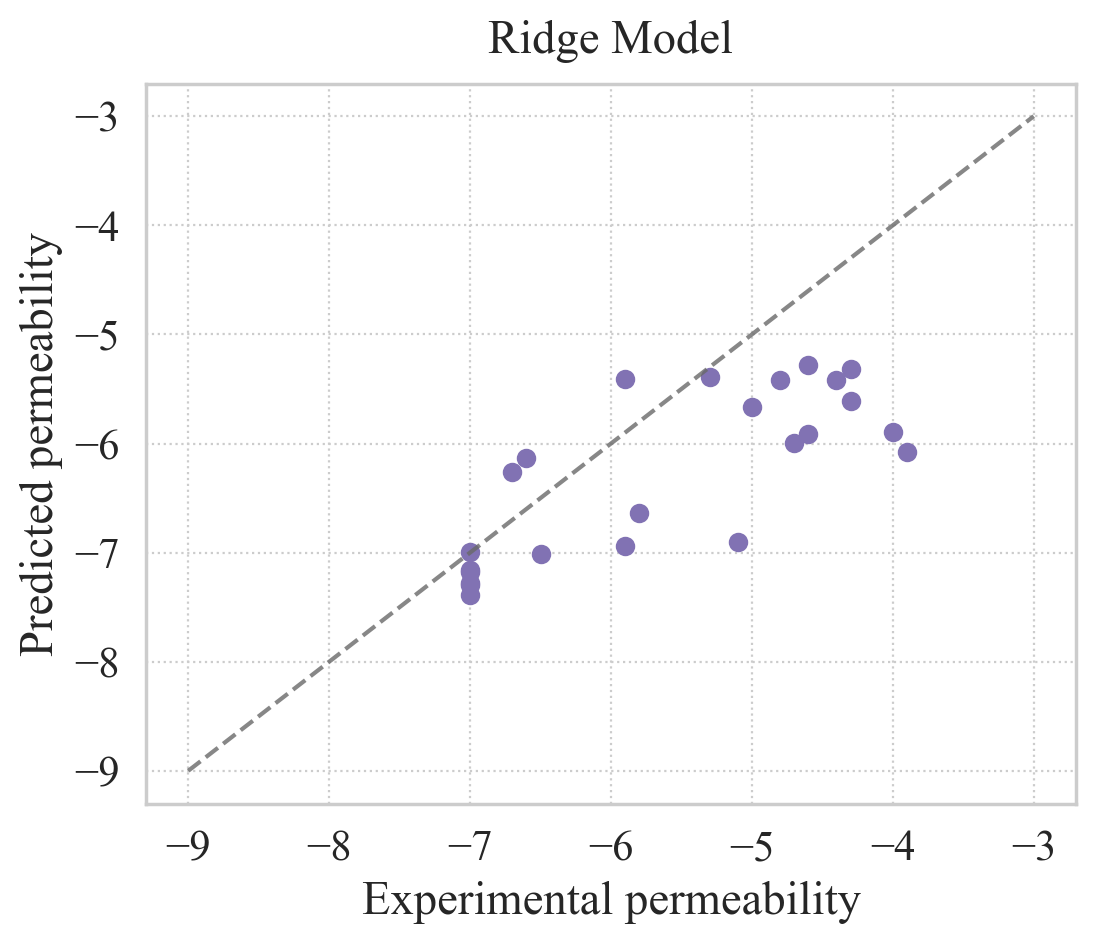

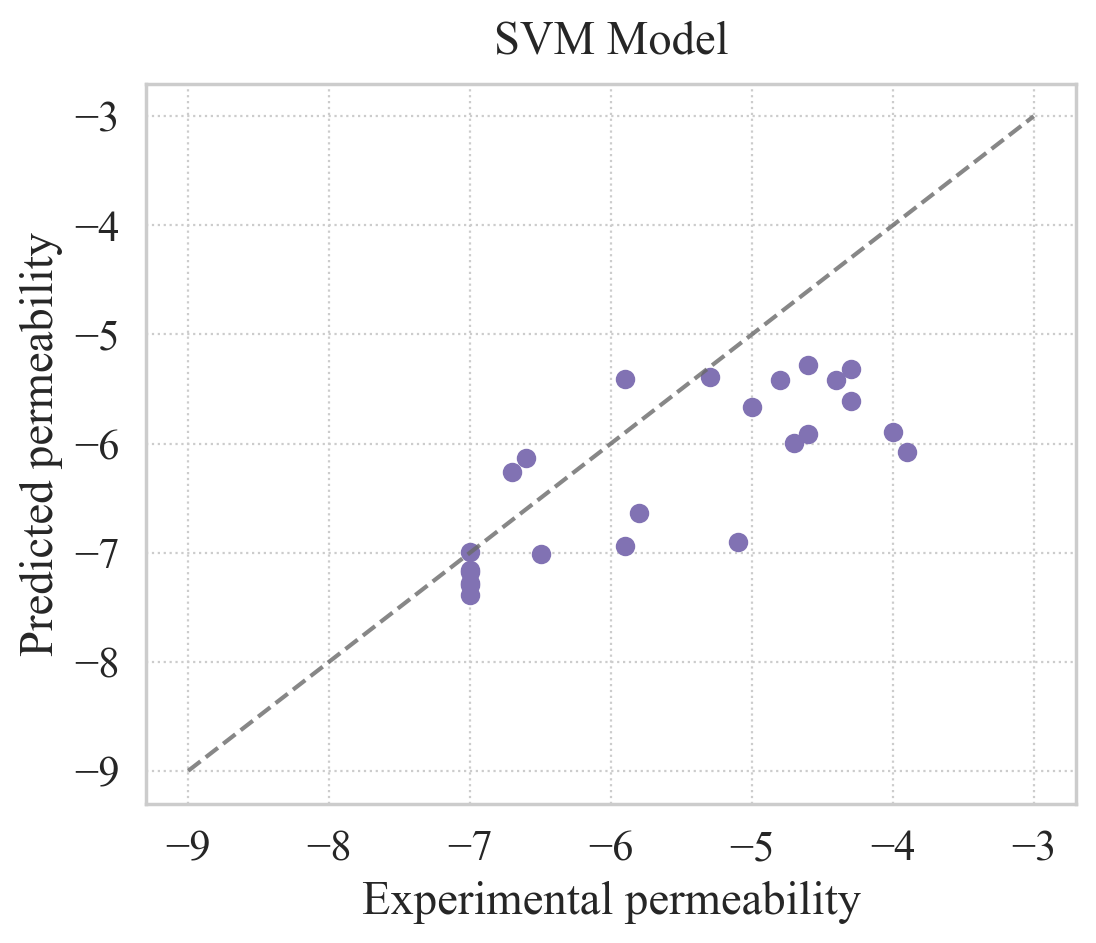

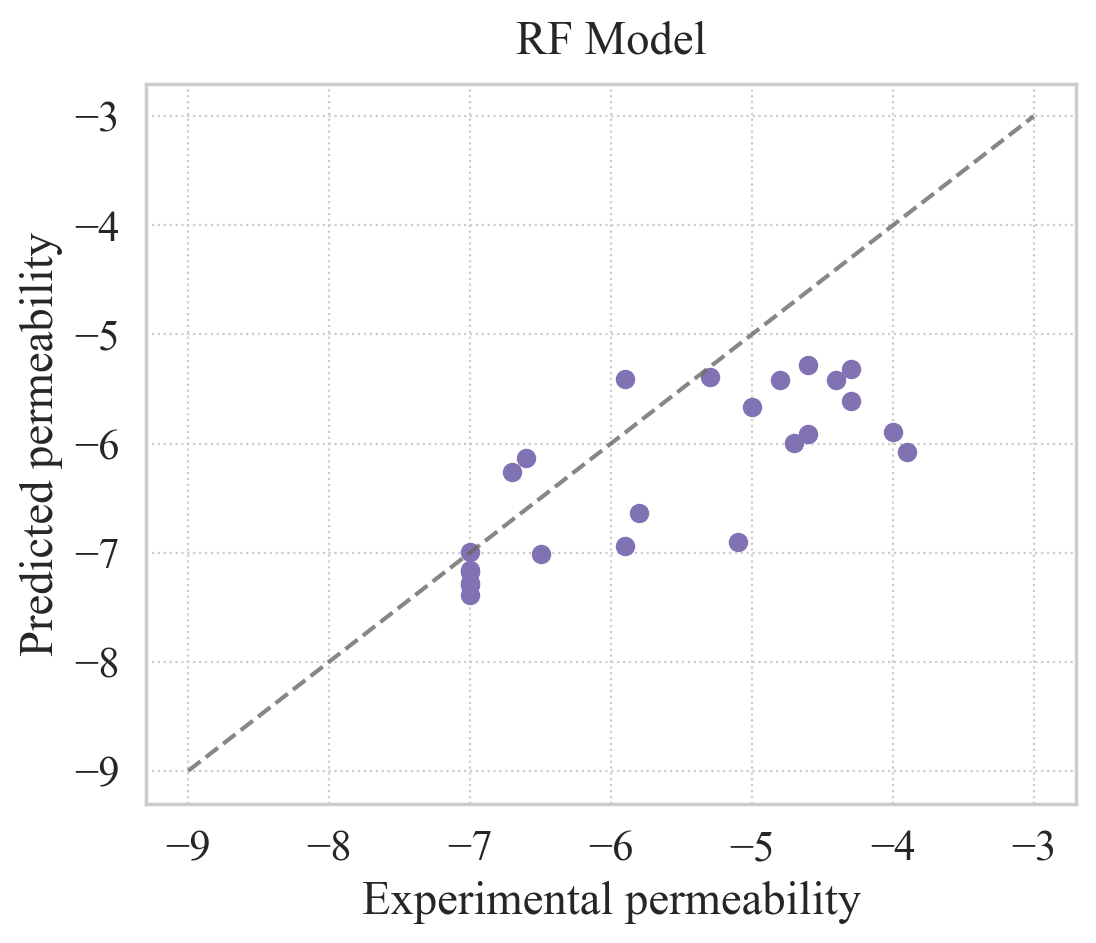

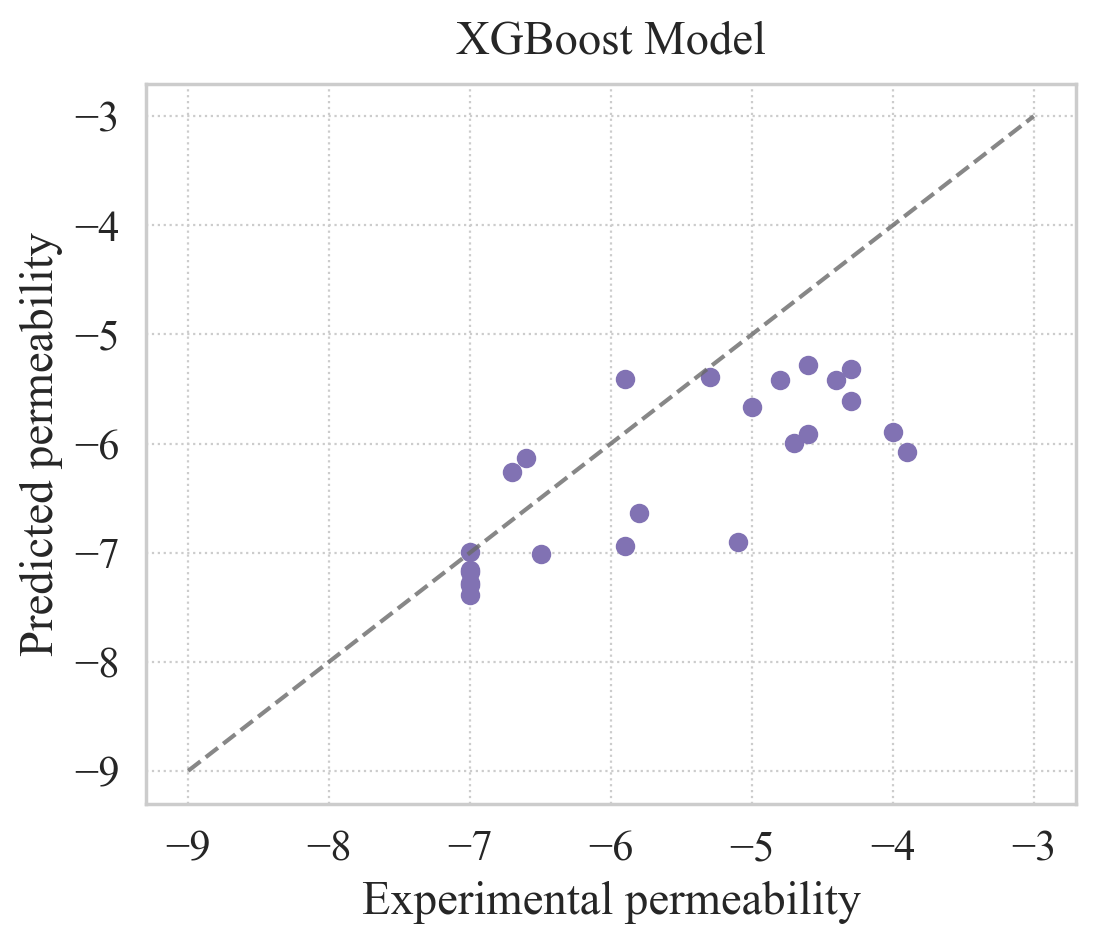

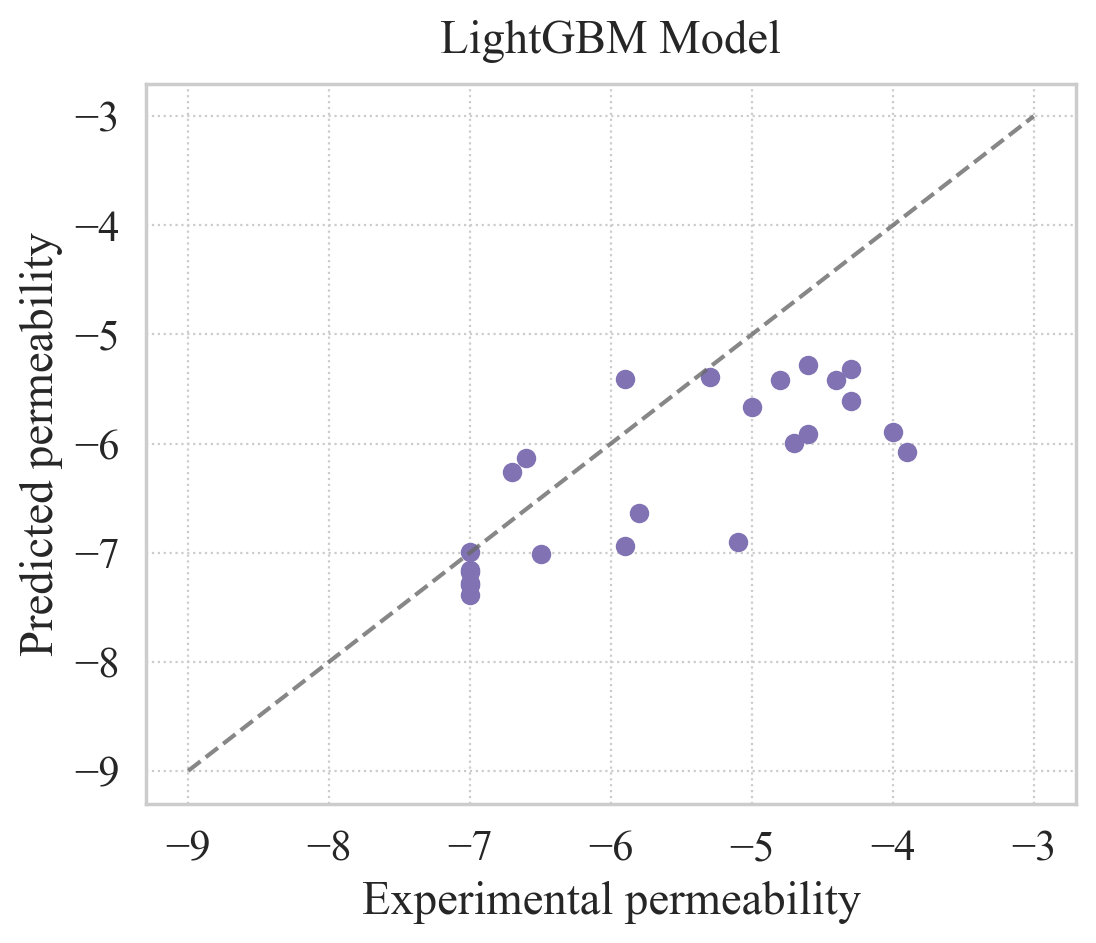

In [33]:
model_name = ['Lasso', 'Ridge', 'SVM', 'RF', 'XGBoost', 'LightGBM']

for name in model_name:
    metrics = pd.read_csv(f'predicted/test_2/{name}_newdata_metrics.csv', index_col=0)

    pred = pd.read_csv(f'predicted/test_2/{name}_newdata_predicted.csv')
    plot_functions.plot_scatter(
        [pred['exp'].to_list()], [pred['pred'].to_list()],
        label_list=[f"MAE: {metrics['MAE'][0]:.2f}, R: {metrics['R'][0]:.2f}"],
        x_name='Experimental permeability', y_name='Predicted permeability', fig_name='',
        title=f'{name} Model',
        x_ticks=None, y_ticks=None, xlim=None, ylim=None,
        fontweight='bold',
        color_list=[COLOR_DICT['Wang2021']], alpha_list=[1], mark_list=None, s=None,
        legend=False,
        diagonal=True, plot_linear=None,
        )

### Shap analysis for the test data

In [34]:
    # ======================
    #       shap analysis
    # ======================


    model.fit(X.to_numpy(), y)
    X_test_shap = X.iloc[new_data_index]

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_shap)


    shap_values_df = pd.DataFrame(
        shap_values,
        columns=X_test_shap.columns,
        index=new_data_index
    )
    shap_values_df.to_csv(
        f'predicted/test_2/{name}_newdata_shap_values.csv'
    )

    #Calculate and save the global importance using mean(|SHAP|)
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_importance_df = pd.DataFrame({
        'feature': X_test_shap.columns,
        'mean_abs_shap': mean_abs_shap
    }).sort_values('mean_abs_shap', ascending=False)

    shap_importance_df.to_csv(
        f'predicted/test_2/{name}_newdata_shap_importance.csv',
        index=False
    )


    top10_features = shap_importance_df['feature'].head(10).tolist()

    #Summary beeswarm plot
    plt.figure()
    shap.summary_plot(
        shap_values,
        X_test_shap,
        show=False,
        max_display=10  # 上位10特徴量のみ表示
    )
    plt.tight_layout()
    plt.savefig(f'predicted/test_2/{name}_newdata_shap_summary_top10.png', dpi=300)
    plt.close()

    # save Top 10 dependence plot
    for feat in top10_features:
        plt.figure()
        shap.dependence_plot(
            feat,
            shap_values,
            X_test_shap,
            show=False
        )
        plt.tight_layout()
        plt.savefig(
            f'predicted/{name}_newdata_shap_dependence_{feat}.png',
            dpi=300
        )
        plt.close()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>